In [1]:
import pandas, numpy, scipy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [6]:
input_file = '/Users/adrian/research/bmcbf/017.grotta/results/deseq2/DESeq2_TPM_values.tsv'

# 1. read expression

In [7]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(38395, 27)


,PN1_Rep1,PN1_Rep2,PN1_Rep3,PN2_Rep1,PN2_Rep2,PN2_Rep3,PN45_Rep1,PN45_Rep2,PN45_Rep3,PN5_Rep1,...,PN6_Rep3,PN73_Rep1,PN73_Rep2,PN73_Rep3,PN76_Rep1,PN76_Rep2,PN76_Rep3,PN78_Rep1,PN78_Rep2,PN78_Rep3
ENSG00000000003,10.122414,10.543560,8.146297,11.575222,11.044924,10.526617,7.503947,8.264207,8.330689,11.195170,...,10.302469,9.118019,10.933290,11.921478,8.380844,10.661781,8.473209,9.415951,10.513514,9.135827
ENSG00000000005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419,120.264945,136.852610,119.517895,106.214562,83.181873,132.878471,110.350042,117.041729,107.373803,130.898433,...,120.776718,134.201733,144.334136,114.305216,115.656144,136.790796,121.093252,118.208264,131.926734,107.187223
ENSG00000000457,9.129377,7.904821,7.754270,10.294455,8.798602,7.354716,7.537981,6.892151,6.062951,7.428272,...,6.847208,6.737131,7.899558,7.781015,8.078524,8.812817,7.245416,7.968219,6.481665,6.362192
ENSG00000000460,21.793836,20.960149,24.987073,25.787501,19.066463,37.550493,25.068606,22.570635,26.965159,19.430736,...,28.773363,28.285520,31.798228,38.604304,27.052848,26.853124,36.557367,22.246664,23.190983,25.031213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000310523,7.978095,8.205170,7.510811,10.560101,8.739442,8.085244,6.338941,6.429169,7.213269,8.376367,...,7.571788,8.479748,7.054364,6.363109,8.230513,9.335501,9.132624,8.136352,8.293833,8.945930
ENSG00000310525,5.255704,6.022466,8.774375,7.915760,18.718412,9.817903,7.349342,8.973524,11.400944,7.679488,...,9.356050,9.570782,14.730881,8.554332,7.651624,12.713282,3.102657,8.513625,4.648349,3.895983
ENSG00000310528,0.460476,0.000000,0.144973,0.133706,0.187225,0.317973,0.400791,0.271106,0.325301,0.337757,...,0.669037,0.105164,0.481889,0.472540,0.283169,1.017582,0.702792,0.464964,0.098633,0.000000
ENSG00000310530,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [8]:
for element in expression.columns:
    print(element)

PN1_Rep1
PN1_Rep2
PN1_Rep3
PN2_Rep1
PN2_Rep2
PN2_Rep3
PN45_Rep1
PN45_Rep2
PN45_Rep3
PN5_Rep1
PN5_Rep2
PN5_Rep3
PN55_Rep1
PN55_Rep2
PN55_Rep3
PN6_Rep1
PN6_Rep2
PN6_Rep3
PN73_Rep1
PN73_Rep2
PN73_Rep3
PN76_Rep1
PN76_Rep2
PN76_Rep3
PN78_Rep1
PN78_Rep2
PN78_Rep3


# 3. filter and transform

In [10]:
substantial_expression = expression[expression.max(axis=1) >= 5]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(11792, 27)
(2222, 27)


In [11]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [12]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.27901989 0.23260823]


PN1_Rep1
PN1_Rep2
PN1_Rep3
PN2_Rep1
PN2_Rep2
PN2_Rep3
PN45_Rep1
PN45_Rep2
PN45_Rep3
PN5_Rep1
PN5_Rep2
PN5_Rep3
PN55_Rep1
PN55_Rep2
PN55_Rep3
PN6_Rep1
PN6_Rep2
PN6_Rep3
PN73_Rep1
PN73_Rep2
PN73_Rep3
PN76_Rep1
PN76_Rep2
PN76_Rep3
PN78_Rep1
PN78_Rep2
PN78_Rep3


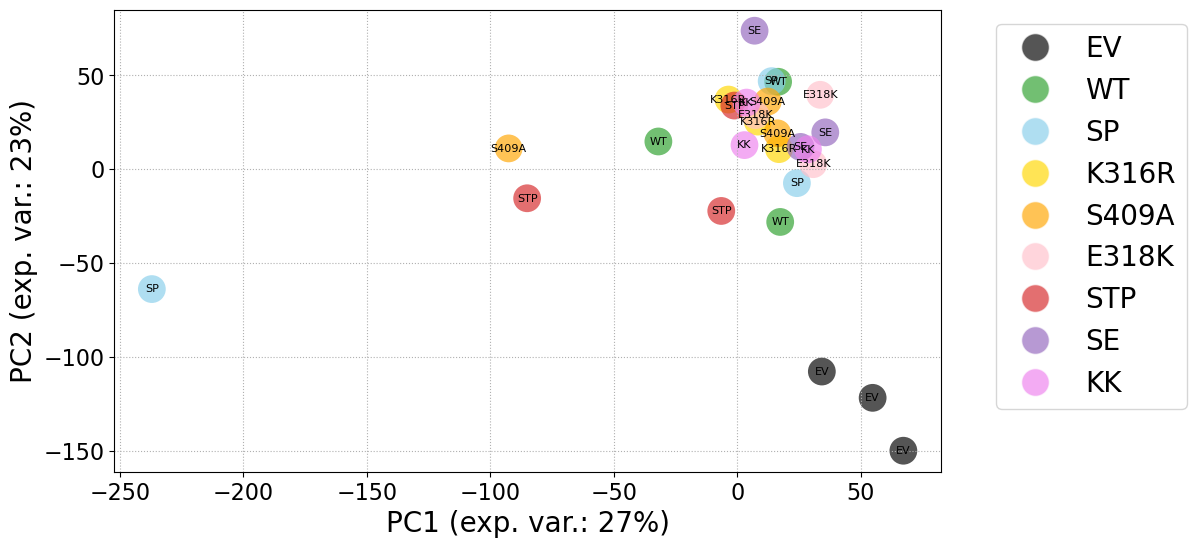

In [30]:
for i in range(len(new)):

    # labels
    identifier = expression.columns[i]
    print(identifier)
    if 'PN1_' in identifier:
        label = 'EV'
        color = 'black'
    elif 'PN2_' in identifier:
        label = 'WT'
        color = 'tab:green'
    elif 'PN5_' in identifier:
        label = 'SP'
        color = 'skyblue'
        
    elif 'PN45_' in identifier:
        color = 'gold'
        label = 'K316R'
    elif 'PN55_' in identifier:
        color = 'orange'
        label = 'S409A'
    elif 'PN73_' in identifier:
        color = 'pink'
        label = 'E318K'
    
    elif 'PN6_' in identifier:
        color = 'tab:red'
        label = 'STP'

    elif 'PN76_' in identifier:
        color = 'tab:purple'
        label = 'SE'
    elif 'PN78_' in identifier:
        color = 'violet'
        label = 'KK'
        
    else:
        print('\t',identifier)
        label = 'undefined'
        color = 'black'

    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=400, c=color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, label, size=8, va='center', ha='center')

legend_elements = [
    
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:green', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='gold', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='orange', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='pink', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:purple', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='violet', markeredgecolor='white', markersize=20, alpha=2/3),
    
]

matplotlib.pyplot.legend(legend_elements, ['EV', 'WT', 'SP', 'K316R', 'S409A', 'E318K', 'STP', 'SE', 'KK'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()

# 4. visualize high expression

In [31]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.36572748 0.25746399]


PN1_Rep1
PN1_Rep2
PN1_Rep3
PN2_Rep1
PN2_Rep2
PN2_Rep3
PN45_Rep1
PN45_Rep2
PN45_Rep3
PN5_Rep1
PN5_Rep2
PN5_Rep3
PN55_Rep1
PN55_Rep2
PN55_Rep3
PN6_Rep1
PN6_Rep2
PN6_Rep3
PN73_Rep1
PN73_Rep2
PN73_Rep3
PN76_Rep1
PN76_Rep2
PN76_Rep3
PN78_Rep1
PN78_Rep2
PN78_Rep3


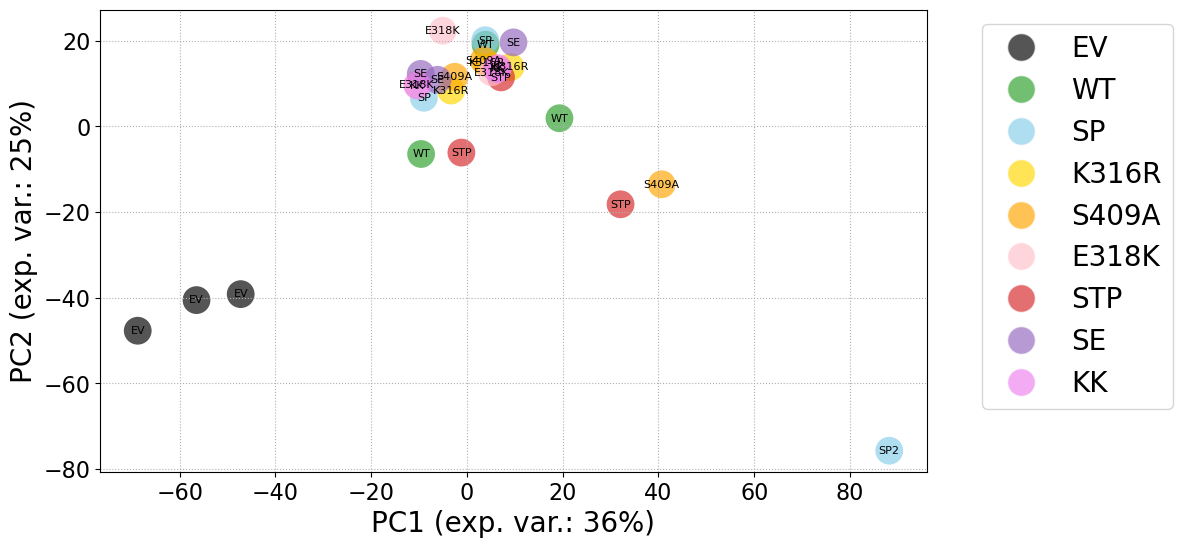

In [46]:
for i in range(len(new)):

    # labels
    identifier = expression.columns[i]
    print(identifier)
    if 'PN1_' in identifier:
        label = 'EV'
        color = 'black'
    elif 'PN2_' in identifier:
        label = 'WT'
        color = 'tab:green'
    elif 'PN5_' in identifier:
        label = 'SP'
        color = 'skyblue'
        if '2' in identifier:
            label='SP2'
        
    elif 'PN45_' in identifier:
        color = 'gold'
        label = 'K316R'
    elif 'PN55_' in identifier:
        color = 'orange'
        label = 'S409A'
    elif 'PN73_' in identifier:
        color = 'pink'
        label = 'E318K'
    
    elif 'PN6_' in identifier:
        color = 'tab:red'
        label = 'STP'

    elif 'PN76_' in identifier:
        color = 'tab:purple'
        label = 'SE'
    elif 'PN78_' in identifier:
        color = 'violet'
        label = 'KK'
        
    else:
        print('\t',identifier)
        label = 'undefined'
        color = 'black'

    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=400, c=color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, label, size=8, va='center', ha='center')

legend_elements = [
    
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:green', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='gold', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='orange', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='pink', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:purple', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='violet', markeredgecolor='white', markersize=20, alpha=2/3),
    
]

matplotlib.pyplot.legend(legend_elements, ['EV', 'WT', 'SP', 'K316R', 'S409A', 'E318K', 'STP', 'SE', 'KK'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()

In [13]:
# 5. distributions

In [34]:
log2_tpm_PO = numpy.log2(expression + 1)
log2_tpm_PO.head()

,PN1_Rep1,PN1_Rep2,PN1_Rep3,PN2_Rep1,PN2_Rep2,PN2_Rep3,PN45_Rep1,PN45_Rep2,PN45_Rep3,PN5_Rep1,...,PN6_Rep3,PN73_Rep1,PN73_Rep2,PN73_Rep3,PN76_Rep1,PN76_Rep2,PN76_Rep3,PN78_Rep1,PN78_Rep2,PN78_Rep3
ENSG00000000003,3.475398,3.529016,3.193188,3.652512,3.590353,3.526897,3.088133,3.211667,3.221984,3.608238,...,3.498566,3.338855,3.576920,3.691699,3.229718,3.543716,3.243853,3.380723,3.525256,3.341392
ENSG00000000005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419,6.922019,7.106983,6.913104,6.744357,6.395438,7.064780,6.798958,6.883153,6.759872,7.043284,...,6.928095,7.078970,7.183230,6.849314,6.866118,7.106336,6.931840,6.897340,7.054487,6.757386
ENSG00000000457,3.340474,3.154587,3.129987,3.497543,3.292576,3.062591,3.093895,2.980418,2.820271,3.075237,...,2.972179,2.951799,3.153734,3.134388,3.182458,3.294667,3.043592,3.164821,2.903359,2.880135
ENSG00000000460,4.510572,4.456816,4.699722,4.743488,4.326714,5.268677,4.704242,4.558919,4.805559,4.352669,...,4.895950,4.872116,5.035546,5.307585,4.810075,4.799767,5.231024,4.538952,4.596397,4.702171


180
17.71957225985374


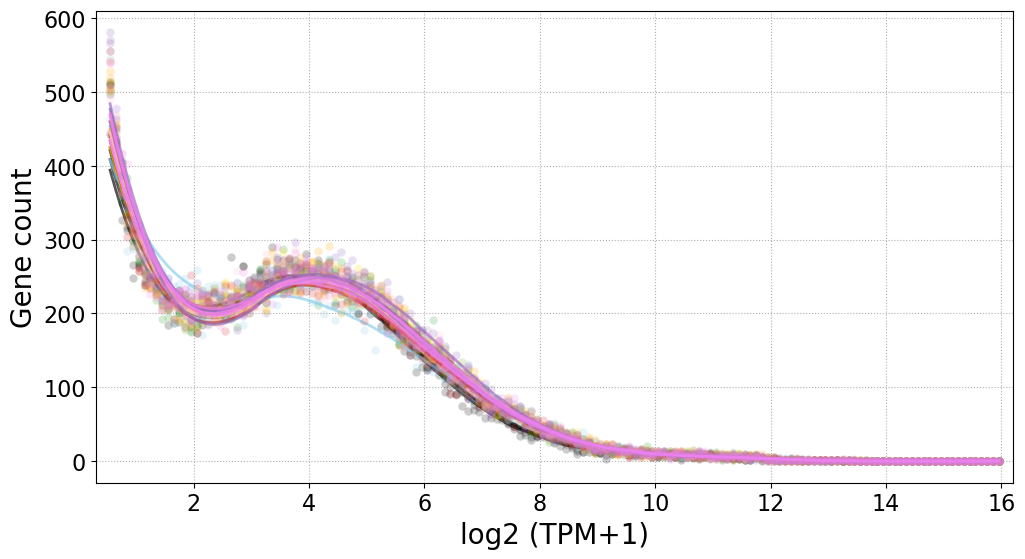

In [43]:
found_max = 18
number_of_bins = int(found_max*10)
print(number_of_bins)

absolute_max = 0
working_samples = log2_tpm_PO.columns.to_list()

most_likely_expressions = []
all_hats = []
for i in range(len(working_samples)):

    identifier = working_samples[i]

    if 'PN1_' in identifier:
        color = 'black'
    elif 'PN2_' in identifier:
        color = 'tab:green'
    elif 'PN5_' in identifier:
        color = 'skyblue'
        
    elif 'PN45_' in identifier:
        color = 'gold'
    elif 'PN55_' in identifier:
        color = 'orange'
    elif 'PN73_' in identifier:
        color = 'pink'
    
    elif 'PN6_' in identifier:
        color = 'tab:red'

    elif 'PN76_' in identifier:
        color = 'tab:purple'
    elif 'PN78_' in identifier:
        color = 'violet'
        
    else:
        print('\t',identifier)
        color = 'black'
    
    log2TPM = log2_tpm_PO.loc[:, identifier]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
  
    plotting_x = x[5:-20]
    plotting_hist = hist[5:-20]
    #print(plotting_x)
    
    matplotlib.pyplot.plot(plotting_x, plotting_hist, 'o', alpha=1/5, mec='none', color=color)
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)

    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=2, alpha=2/3, color=color)
    
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])
#matplotlib.pyplot.ylim([0, 400])

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)